In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm
import xarray as xr

In [13]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

'notebook'

# Figure C3-1: Electrode Coverage

This figure demonstrates comprehensive SEEG electrode coverage across all patients and dense sampling of the AIC.

In [14]:
from scipy.spatial import cKDTree
from mne.viz import Brain
import pyvista as pv
import re

ref = 'bipolar'
task = [
    'PhonemeSequence',
    'SentenceRep',
    'LexicalDelay',
    'LexicalNoDelay',
    'PictureNaming',
]

# Electrode coordinates from package_ave_cord.py (results/*/HGA/*_coord.csv).
# Each file lists all sampled electrodes for one subject/task/phase (not significant-only).
# Do not load zscore CSVs here — those are time-resolved stats, not electrode locations.
coord_paths = []
coord_paths.extend(
    BIDSPath(
        root=f'../results/{t}({ref})',
        datatype='HGA',
        suffix='coord',
        check=False,
    ).match()
    for t in task
)

coord_paths = np.concatenate(coord_paths).tolist()

coords = []
for path in tqdm(coord_paths):
    df = pd.read_csv(path)
    coords.append(df)

coords = pd.concat(coords, ignore_index=True)
coords.loc[coords.roi == 'INS', 'roi'] = 'Insula'
coords.loc[coords.roi == 'HG', 'roi'] = 'STG'
coords.loc[coords.roi == 'PrG', 'roi'] = 'SMC'
coords.loc[coords.roi == 'PoG', 'roi'] = 'SMC'
coords.loc[coords.roi == 'Subcentral', 'roi'] = 'SMC'

print(f'Loaded {len(coord_paths)} coord files from {len(task)} tasks')
print(f'Rows: {len(coords):,}; unique electrodes: {coords.channel.nunique():,}; subjects: {coords.subject.nunique()}')

coords.head()

100%|██████████| 693/693 [00:01<00:00, 419.23it/s]


,channel,x,y,z,HGA,significant,subject,task,band,description,phase,label,roi,hemi
0,D0019_ROG1-2,20.731562,-95.433053,-4.406237,-0.041696,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_Pole_occipital,OPC,R
1,D0019_ROG2-3,18.712896,-94.417750,6.523434,0.027467,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_Pole_occipital,OPC,R
2,D0019_ROG3-4,17.039880,-94.822626,17.317047,0.047800,False,D0019,PhonemeSequence,highgamma,Repeat,Go,Unknown,Unknown,R
3,D0019_ROG4-5,16.298644,-91.860079,29.446276,0.044848,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_G_occipital_sup,sOccG,R
4,D0019_ROG5-6,13.397947,-84.402838,39.447554,0.003595,False,D0019,PhonemeSequence,highgamma,Repeat,Go,Unknown,Unknown,R


In [15]:
def classify_insula_ap(coords_df, y_threshold=0):
    """
    Classify insula electrodes into AIC (anterior insula cortex) and PIC (posterior insula cortex).
    This follows the rule used in the paper figure notebooks.
    """
    coords_classified = coords_df.copy()
    coords_classified['insula_region'] = coords_classified['roi']

    insula_mask = coords_classified['roi'] == 'Insula'
    label = coords_classified['label'].fillna('')

    aic_conditions = (
        label.str.contains('G_insular_short') |
        label.str.contains('S_circular_insula_ant') |
        (label.str.contains('S_circular_insula_sup') & (coords_classified['y'] > y_threshold)) |
        (label.str.contains('S_circular_insula_inf') & (coords_classified['y'] > y_threshold))
    )

    pic_conditions = (
        label.str.contains('G_Ins_lg_and_S_cent_ins') |
        (label.str.contains('S_circular_insula_sup') & (coords_classified['y'] <= y_threshold)) |
        (label.str.contains('S_circular_insula_inf') & (coords_classified['y'] <= y_threshold))
    )

    coords_classified.loc[insula_mask & aic_conditions, 'roi'] = 'AIC'
    coords_classified.loc[insula_mask & pic_conditions, 'roi'] = 'PIC'

    return coords_classified

coords_ap = classify_insula_ap(coords)
print(f"AIC electrode count: {len(coords_ap[coords_ap['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(coords_ap[coords_ap['roi'] == 'PIC'])}")

AIC electrode count: 1453
PIC electrode count: 1482


## Panel A: Whole-Brain Electrode Coverage

Subjects with AIC: 44
Electrodes plotted: 6025 (AIC: 159)
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-05-23 11:01:22.311 ( 818.606s) [    7F966474C740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xb560b7c0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

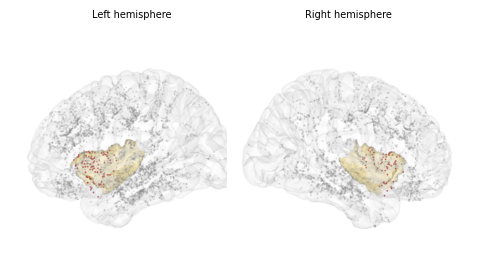

In [16]:
subjects_with_aic = coords_ap.loc[coords_ap['roi'] == 'AIC', 'subject'].unique()
roi_priority = {'AIC': 0, 'PIC': 1, 'Insula': 2}
coords_sorted = coords_ap.assign(
    _roi_pri=coords_ap['roi'].map(roi_priority).fillna(99)
).sort_values('_roi_pri')
coords_wb = (
    coords_sorted[coords_sorted['subject'].isin(subjects_with_aic)]
    .drop_duplicates(subset=['channel'])
    .drop(columns='_roi_pri')
)
aic_mask = coords_wb['roi'].eq('AIC').values
print(f"Subjects with AIC: {len(subjects_with_aic)}")
print(f"Electrodes plotted: {len(coords_wb)} (AIC: {aic_mask.sum()})")

labels = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152', parc='aparc.a2009s',
    surf_name='pial', hemi='both', subjects_dir=recon_dir
)

lh_brain = Brain(
    'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial',
    hemi='lh', background='white', show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(800, 800)
)
rh_brain = Brain(
    'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial',
    hemi='rh', background='white', show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(800, 800)
)

cord_fsavg = coords_wb[['x', 'y', 'z']].values

fsavg_lh_surf, _ = mne.read_surface(f'{recon_dir}/fsaverage/surf/lh.pial')
cvs_lh_surf, _ = mne.read_surface(f'{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial')
translation = cvs_lh_surf.mean(axis=0) - fsavg_lh_surf.mean(axis=0)
cord = cord_fsavg + translation

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

lh_pial_coords, _ = mne.read_surface(f'{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial')
rh_pial_coords, _ = mne.read_surface(f'{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial')
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

insula_patterns = [
    'G_insular_short',
    'G_Ins_lg_and_S_cent_ins',
    'S_circular_insula_ant',
    'S_circular_insula_inf',
    'S_circular_insula_sup',
]

for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)

def on_surface_mask(indices, labels, hemi):
    """Keep electrodes whose nearest pial vertex falls on cortex labels."""
    valid = np.zeros(len(indices), dtype=bool)
    for i, idx in enumerate(indices):
        for lab in labels:
            if lab.hemi == hemi and idx in lab.vertices:
                valid[i] = True
                break
    return valid


if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_is_aic = aic_mask[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_projected_coords = lh_pial_coords[lh_indices]
    lh_valid = on_surface_mask(lh_indices, labels, 'lh')

    if (lh_valid & ~lh_is_aic).any():
        cloud = pv.PolyData(lh_projected_coords[lh_valid & ~lh_is_aic])
        lh_brain._renderer.plotter.add_mesh(
            cloud, render_points_as_spheres=True, point_size=10,
            color='gray', lighting=False, smooth_shading=False, opacity=0.3,
        )
    if (lh_valid & lh_is_aic).any():
        cloud = pv.PolyData(lh_projected_coords[lh_valid & lh_is_aic])
        lh_brain._renderer.plotter.add_mesh(
            cloud, render_points_as_spheres=True, point_size=10,
            color=red, lighting=False, smooth_shading=False, opacity=0.9,
        )

if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_is_aic = aic_mask[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_projected_coords = rh_pial_coords[rh_indices]
    rh_valid = on_surface_mask(rh_indices, labels, 'rh')

    if (rh_valid & ~rh_is_aic).any():
        cloud = pv.PolyData(rh_projected_coords[rh_valid & ~rh_is_aic])
        rh_brain._renderer.plotter.add_mesh(
            cloud, render_points_as_spheres=True, point_size=10,
            color='gray', lighting=False, smooth_shading=False, opacity=0.3,
        )
    if (rh_valid & rh_is_aic).any():
        cloud = pv.PolyData(rh_projected_coords[rh_valid & rh_is_aic])
        rh_brain._renderer.plotter.add_mesh(
            cloud, render_points_as_spheres=True, point_size=10,
            color=red, lighting=False, smooth_shading=False, opacity=0.9,
        )

for brain in (lh_brain, rh_brain):
    brain.show_view(view='lateral', distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, axes = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm), gridspec_kw={'width_ratios': [1, 1]})
plt.subplots_adjust(wspace=-0.2)

axes[0].imshow(lh_brain.screenshot(mode='rgb'))
axes[0].axis('off')
axes[0].set_title('Left hemisphere', fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode='rgb'))
axes[1].axis('off')
axes[1].set_title('Right hemisphere', fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.savefig('grantfig/c3_1_whole_brain_electrode_coverage.svg', dpi=300, bbox_inches='tight')
plt.show()

## Panel B: AIC Electrode Coverage

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-05-23 11:05:56.756 (1093.051s) [    7F966474C740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xb3d4110): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card

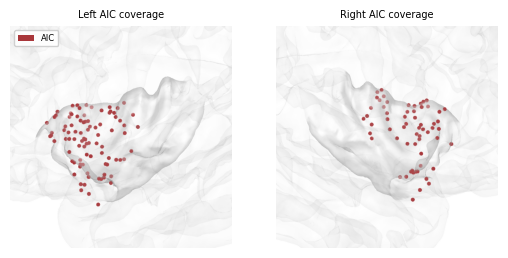

In [18]:
aic_coords = coords_ap.drop_duplicates(subset=['channel'])
aic_coords = aic_coords[aic_coords['roi'] == 'AIC'].copy()

cord = aic_coords[['x', 'y', 'z']].values + translation

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

labels = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152', parc='aparc.a2009s',
    surf_name='pial', hemi='both', subjects_dir=recon_dir
)

lh_brain = Brain(
    'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial',
    hemi='lh', background='white', show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial',
    hemi='rh', background='white', show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)

for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)


def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(pattern in lab.name for pattern in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        return pial_coords[vertices].mean(axis=0)
    return None


lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)


def add_aic_electrodes(brain, coords_h, tree, pial_coords):
    _, indices = tree.query(coords_h)
    coords_proj = pial_coords[indices]

    for pt in coords_proj:
        cloud = pv.PolyData(pt[np.newaxis, :])
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=14,
            color=red,
            lighting=False,
        )


if mask_lh.any():
    add_aic_electrodes(lh_brain, cord[mask_lh], lh_tree, lh_pial_coords)

if mask_rh.any():
    add_aic_electrodes(rh_brain, cord[mask_rh], rh_tree, rh_pial_coords)

lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

fig, axes = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))

axes[0].imshow(lh_brain.screenshot(mode='rgb'))
axes[0].axis('off')
axes[0].set_title('Left AIC coverage', fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode='rgb'))
axes[1].axis('off')
axes[1].set_title('Right AIC coverage', fontsize=fontsize)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=red, label='AIC')]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

lh_brain.close()
rh_brain.close()

plt.savefig('grantfig/c3_1_aic_electrode_coverage.svg', dpi=300, bbox_inches='tight')
plt.show()

# Figure C3-2: AIC Electrode and Signal Characterization

This figure demonstrates the recording methodology and signal quality from AIC electrodes.

## Panel A: Example SEEG Strip Sampling AIC

Reading /cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/derivatives/epoch(bipolar)/sub-D0094/epoch(band)(zscore)/sub-D0094_task-PhonemeSequence_proc-Delay_desc-Repeat_highgamma.h5 ...


    Found the data of interest:
        t =   -1000.00 ...    1492.19 ms
        0 CTF compensation matrices available
Not setting metadata
28 matching events found
No baseline correction applied
0 projection items activated


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1545013/457579780.py:18: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/derivatives/epoch(bipolar)/sub-D0094/epoch(band)(zscore)/sub-D0094_task-PhonemeSequence_proc-Delay_desc-Repeat_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epoch_path, preload=True)
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-05-23 11:19:18.694 (1894.989s) [    7F966474C740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xdfc3150): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: fa

Strips containing insula electrodes: ['D0094_LFAI' 'D0094_LFPI' 'D0094_LPAI' 'D0094_LIA' 'D0094_LTAS']
Total electrodes in insula strips: 58
  AIC: 5, PIC: 3, Other: 50


 egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-05-23 11:19:18.756 (1895.051s) [    7F966474C740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xdfc3150): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission d

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/D94/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/D94/label/rh.aparc.a2009s.annot


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-05-23 11:19:19.875 (1896.170s) [    7F966474C740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x13b39100): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/D94/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/D94/label/rh.aparc.a2009s.annot


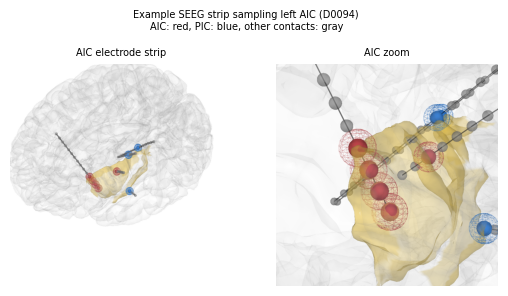

In [24]:
# Example subject used in the paper Figure 1 AIC strip view.
sub = 'D0094'
subid = 'D94'
bids_root = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/'

sub_coords_roi = coords_ap[coords_ap.subject == sub].groupby('channel').first()

epoch_paths = BIDSPath(
    root=os.path.join(bids_root, f'derivatives/epoch({ref})'),
    subject=sub,
    suffix='highgamma',
    datatype='epoch(band)(zscore)',
    extension='.h5',
    check=False,
)

epoch_path = epoch_paths.match()[0]
epochs = mne.read_epochs(epoch_path, preload=True)
montage = epochs.get_montage()
subj_coords = pd.DataFrame(montage.get_positions()['ch_pos']).T
subj_coords.columns = ['x', 'y', 'z']
subj_coords[['x', 'y', 'z']] *= 1000
subj_coords = subj_coords.join(sub_coords_roi[['roi']], how='left')


def get_strip_prefix(ch_name):
    parts = ch_name.split('_', 1)
    if len(parts) == 2:
        subj_name, elec = parts
        alpha_prefix = re.match(r'[A-Za-z]+', elec)
        if alpha_prefix:
            return f'{subj_name}_{alpha_prefix.group()}'
    return ch_name


subj_coords['strip'] = [get_strip_prefix(ch) for ch in subj_coords.index]
insula_channels = subj_coords[subj_coords['roi'].isin(['AIC', 'PIC'])].index
insula_strips = subj_coords.loc[insula_channels, 'strip'].unique()
insula_strips = insula_strips[insula_strips != 'D0088_LTAS']

strip_electrodes = subj_coords[subj_coords['strip'].isin(insula_strips)].copy()

print(f'Strips containing insula electrodes: {insula_strips}')
print(f'Total electrodes in insula strips: {len(strip_electrodes)}')
other_count = (~strip_electrodes['roi'].isin(['AIC', 'PIC'])).sum()
print(f"  AIC: {(strip_electrodes['roi'] == 'AIC').sum()}, PIC: {(strip_electrodes['roi'] == 'PIC').sum()}, Other: {other_count}")


def build_insula_brain(hemi='lh', cortex_alpha=0.1):
    brain = Brain(
        subid,
        subjects_dir=recon_dir,
        surf='pial',
        hemi=hemi,
        background='white',
        show=False,
        cortex=(0.9, 0.9, 0.9),
        alpha=cortex_alpha,
        size=(800, 800),
    )

    insula_patterns = [
        'G_insular_short',
        'G_Ins_lg_and_S_cent_ins',
        'S_circular_insula_ant',
        'S_circular_insula_inf',
        'S_circular_insula_sup',
    ]

    labels = mne.read_labels_from_annot(
        subject=subid,
        parc='aparc.a2009s',
        surf_name='pial',
        hemi='both',
        subjects_dir=recon_dir,
    )

    for lab in labels:
        if any(pattern in lab.name for pattern in insula_patterns) and lab.hemi == 'lh':
            brain.add_label(lab, borders=False, color=insula_color, alpha=0.6)

    color_map = {'AIC': red, 'PIC': blue}
    label_radius = 3
    foci_hemi = 'lh' if hemi == 'both' else None

    for strip_name in insula_strips:
        strip_df = strip_electrodes[strip_electrodes['strip'] == strip_name]
        coords_arr = strip_df[['x', 'y', 'z']].values
        rois = strip_df['roi'].values

        for coord, roi in zip(coords_arr, rois):
            color = color_map.get(roi, 'gray')
            alpha = 1 if roi in ('AIC', 'PIC') else 0.5
            size = 0.3 if roi in ('AIC', 'PIC') else 0.2
            foci_kwargs = dict(coords=coord[np.newaxis, :], scale_factor=size, color=color, alpha=alpha)
            if foci_hemi:
                foci_kwargs['hemi'] = foci_hemi
            brain.add_foci(**foci_kwargs)

            if roi in ('AIC', 'PIC'):
                radius_sphere = pv.Sphere(radius=label_radius, center=coord, theta_resolution=12, phi_resolution=12)
                brain._renderer.plotter.add_mesh(
                    radius_sphere,
                    style='wireframe',
                    color=color,
                    line_width=0.5,
                    opacity=0.5,
                )

        if len(coords_arr) > 1:
            for j in range(len(coords_arr) - 1):
                line = pv.Line(coords_arr[j], coords_arr[j + 1])
                brain._renderer.plotter.add_mesh(line, color='black', line_width=5, opacity=0.6)

    return brain, labels, insula_patterns


both_brain, labels, insula_patterns = build_insula_brain(hemi='both', cortex_alpha=0.1)
zoom_brain, _, _ = build_insula_brain(hemi='lh', cortex_alpha=0.05)

lh_pial_coords_sub, _ = mne.read_surface(f'{recon_dir}/{subid}/surf/lh.pial')


def get_subject_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(pattern in lab.name for pattern in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        return pial_coords[vertices].mean(axis=0)
    return None


lh_insula_center_sub = get_subject_insula_center(labels, 'lh', lh_pial_coords_sub)
aic_electrodes = strip_electrodes[strip_electrodes['roi'] == 'AIC']
aic_center = aic_electrodes[['x', 'y', 'z']].values.mean(axis=0) if len(aic_electrodes) > 0 else lh_insula_center_sub

fig, axes = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm), gridspec_kw={'width_ratios': [1, 1]})

both_brain.show_view(azimuth=150, elevation=60, distance=350, focalpoint=lh_insula_center_sub)
axes[0].imshow(both_brain.screenshot(mode='rgb'))
axes[0].axis('off')
axes[0].set_title('AIC electrode strip', fontsize=fontsize)
both_brain.close()

zoom_brain.show_view(azimuth=120, elevation=85, distance=100, focalpoint=aic_center)
axes[1].imshow(zoom_brain.screenshot(mode='rgb'))
axes[1].axis('off')
axes[1].set_title('AIC zoom', fontsize=fontsize)
zoom_brain.close()

fig.suptitle(
    f'Example SEEG strip sampling left AIC ({sub})\nAIC: red, PIC: blue, other contacts: gray',
    fontsize=fontsize,
    y=1.02,
)

plt.savefig('grantfig/c3_2_aic_electrode_strip.svg', dpi=300, bbox_inches='tight')
plt.show()

## Panel B: Example AIC Time-Frequency Signal

This panel reuses the paper Figure 1 example TFR logic. It loads task TFR files and statistics for one AIC channel, then plots significant time-frequency regions across task phases.

['D0088_LAI1-2', 'D0088_LAI5-6', 'D0088_LAI6-7']


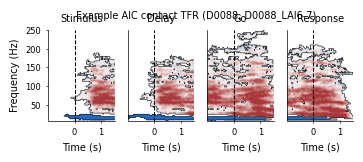

In [19]:
# Example AIC channel from the paper Figure 1 TFR panel.
tfr_bids_root = "/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/"
tfr_subject = "D0088"
tfr_description = "Repeat"
tfr_phases = ["Stimulus", "Delay", "Go", "Response"]

pickchannels = coords_ap[
    (coords_ap.subject == tfr_subject)
    & (coords_ap.roi == "AIC")
].channel.unique().tolist()
print(pickchannels)

# Use the third available AIC channel to match the paper figure code when possible.
channel_idx = 2 if len(pickchannels) > 2 else 0
plot_channel = pickchannels[channel_idx]

tfr_data = {}
stats_data = {}

for phase in tfr_phases:
    tfr_path = BIDSPath(
        root=os.path.join(tfr_bids_root, "derivatives", "tfr"),
        datatype="bipolar",
        suffix="tfr",
        processing=phase,
        extension=".h5",
        check=False,
    ).match()[0]

    tfr_path = tfr_path.copy().update(subject=tfr_subject, description=tfr_description)
    tfr_data[phase] = mne.time_frequency.read_tfrs(tfr_path.fpath, verbose=False)

    stats_path = tfr_path.copy().update(suffix="stats")
    with h5py.File(stats_path.fpath, "r") as stats:
        stats_data[phase] = {
            "mask": stats["mask"][()],
            "pvals": stats["pvals"][()],
        }

idx = {phase: tfr_data[phase].ch_names.index(plot_channel) for phase in tfr_phases}

freqs = tfr_data["Go"].freqs
times = {phase: tfr_data[phase].times for phase in tfr_phases}
ch_data = {phase: tfr_data[phase].get_data()[idx[phase]] for phase in tfr_phases}

p_threshold = 0.05
significant = {
    phase: (stats_data[phase]["pvals"][idx[phase]] < p_threshold)
    & (stats_data[phase]["mask"][idx[phase]] > 0)
    for phase in tfr_phases
}

all_data = np.concatenate([ch_data[phase] for phase in tfr_phases])
vmin, vmax = np.percentile(all_data, [10, 95])

fig, axes = plt.subplots(1, 4, figsize=(10 * cm, 3 * cm))
plt.subplots_adjust(wspace=0.2)

for ax, phase in zip(axes, tfr_phases):
    if np.any(significant[phase]):
        sig_cluster = np.zeros_like(stats_data[phase]["mask"][idx[phase]])
        sig_cluster[significant[phase]] = 1

        sig_data = ch_data[phase].copy()
        sig_data[~significant[phase]] = np.nan

        ax.pcolormesh(
            times[phase],
            freqs,
            sig_data,
            shading="gouraud",
            cmap="vlag",
            rasterized=True,
            vmin=vmin,
            vmax=vmax,
            alpha=0.9,
        )

        ax.contour(
            times[phase],
            freqs,
            sig_cluster,
            levels=[0.5],
            colors="black",
            alpha=0.8,
            linewidths=0.5,
            linestyles="-",
        )

    ax.set_title(phase, fontsize=7)
    ax.set_ylim(10, 250)
    ax.axvline(x=0, color="k", linestyle="--", alpha=1, lw=0.75)

    if phase == "Stimulus":
        ax.set_ylabel("Frequency (Hz)", fontsize=7)
    else:
        ax.set_yticks([])
    ax.set_xlabel("Time (s)", fontsize=7)
    ax.tick_params(labelsize=6, width=0.5, length=1.5, which="both")
    plt.setp(ax.spines.values(), linewidth=0.5)
    sns.despine(ax=ax)

fig.suptitle(f"Example AIC contact TFR ({tfr_subject}, {plot_channel})", fontsize=fontsize, y=1.05)
plt.savefig('grantfig/c3_2_example_aic_tfr.svg', dpi=300, bbox_inches='tight')
plt.show()